# Примеры использования PNN, GRNN и AdaptivePNN

In [3]:
from pathlib import Path
import sys
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import matplotlib.pyplot as plt

from sklearn.datasets import make_circles, make_classification
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold,
    KFold,
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, r2_score

from pnn.pnn import PNN, AdaptivePNN
from grnn.grnn import GRNN

np.random.seed(42)

## 1. PNN

In [4]:
X_raw, y_cls = make_circles(n_samples=800, noise=0.08, factor=0.35, random_state=42)
X_cls = np.c_[X_raw, np.sum(X_raw ** 2, axis=1)]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=42, stratify=y_cls
)

pnn = PNN(bandwidth=0.05, kernel="gaussian", losses="uniform")
pnn.fit(X_train_cls, y_train_cls)

y_pred_cls = pnn.predict(X_test_cls)
acc_cls = accuracy_score(y_test_cls, y_pred_cls)

print(f"Точность PNN на тесте: {acc_cls:.4f}")
print("\nКороткий отчёт по классам:")
print(classification_report(y_test_cls, y_pred_cls, digits=3))

Точность PNN на тесте: 1.0000

Короткий отчёт по классам:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       100
           1      1.000     1.000     1.000       100

    accuracy                          1.000       200
   macro avg      1.000     1.000     1.000       200
weighted avg      1.000     1.000     1.000       200



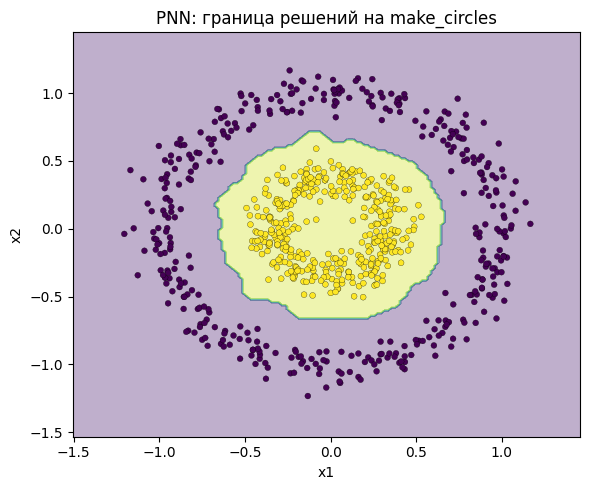

In [5]:
def add_radius_sq(X2):
    return np.c_[X2, np.sum(X2 ** 2, axis=1)]


def plot_decision_boundary_2d(model, X2_raw, y, title, feature_map=None, grid_step=0.02):
    x_min, x_max = X2_raw[:, 0].min() - 0.3, X2_raw[:, 0].max() + 0.3
    y_min, y_max = X2_raw[:, 1].min() - 0.3, X2_raw[:, 1].max() + 0.3

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, grid_step),
        np.arange(y_min, y_max, grid_step),
    )
    grid_raw = np.c_[xx.ravel(), yy.ravel()]
    grid_features = feature_map(grid_raw)

    zz = model.predict(grid_features).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, zz, alpha=0.35)
    plt.scatter(X2_raw[:, 0], X2_raw[:, 1], c=y, s=18, edgecolor="k", linewidths=0.2)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.tight_layout()
    plt.show()


plot_decision_boundary_2d(
    model=pnn,
    X2_raw=X_raw,
    y=y_cls,
    title="PNN: граница решений на make_circles",
    feature_map=add_radius_sq,
)

## 2. Совместимость PNN со `scikit-learn` API

In [6]:
# совместимость с pipeline
pnn_pipeline = Pipeline([
    ("model", PNN(bandwidth=0.1, kernel="gaussian", losses="uniform")),
])

cv_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pnn_pipeline, X_cls, y_cls, cv=cv_cls, scoring="accuracy")

print("CV accuracy по фолдам:", np.round(cv_scores, 4))
print(f"CV accuracy (mean +- std): {cv_scores.mean():.4f} +- {cv_scores.std():.4f}")

# грид поиск, кросс-валидация
pnn_grid = GridSearchCV(
    estimator=pnn_pipeline,
    param_grid={"model__bandwidth": [0.03, 0.05, 0.08, 0.10, 0.15]},
    cv=cv_cls,
    scoring="accuracy",
    n_jobs=1,
)
pnn_grid.fit(X_cls, y_cls)

print("Лучшие параметры PNN:", pnn_grid.best_params_)
print(f"Лучшая CV accuracy: {pnn_grid.best_score_:.4f}")

CV accuracy по фолдам: [1. 1. 1. 1. 1.]
CV accuracy (mean +- std): 1.0000 +- 0.0000
Лучшие параметры PNN: {'model__bandwidth': 0.03}
Лучшая CV accuracy: 1.0000


## 3. Пример GRNN (регрессия)

In [7]:
# синтетический датасет
rng = np.random.default_rng(42)
X_reg = rng.uniform(-4.0, 4.0, size=(500, 1))
y_reg = np.sin(1.5 * X_reg[:, 0]) + 0.2 * rng.normal(size=500)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

grnn = GRNN(bandwidth=0.1, kernel="gaussian")
grnn.fit(X_train_reg, y_train_reg)

y_pred_reg = grnn.predict(X_test_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"GRNN MAE: {mae:.4f}")
print(f"GRNN R2:  {r2:.4f}")

GRNN MAE: 0.1620
GRNN R2:  0.9253


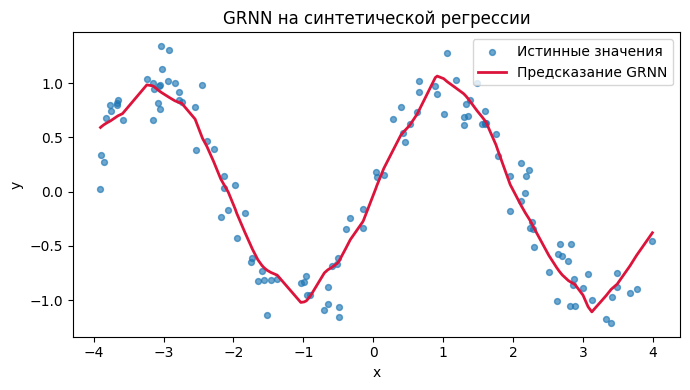

In [8]:
order = np.argsort(X_test_reg[:, 0])

plt.figure(figsize=(7, 4))
plt.scatter(X_test_reg[:, 0], y_test_reg, s=18, alpha=0.65, label="Истинные значения")
plt.plot(
    X_test_reg[order, 0],
    y_pred_reg[order],
    color="crimson",
    linewidth=2,
    label="Предсказание GRNN",
)
plt.title("GRNN на синтетической регрессии")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Совместимость GRNN со `scikit-learn` API

In [9]:
# также pipeline
grnn_pipeline = Pipeline([
    ("model", GRNN(bandwidth=0.30, kernel="gaussian")),
])

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
neg_mae_scores = cross_val_score(
    grnn_pipeline,
    X_reg,
    y_reg,
    cv=cv_reg,
    scoring="neg_mean_absolute_error",
)

print("CV MAE по фолдам:", np.round(-neg_mae_scores, 4))
print(f"CV MAE (mean +- std): {-neg_mae_scores.mean():.4f} +- {neg_mae_scores.std():.4f}")

# GridSearchCV
grnn_grid = GridSearchCV(
    estimator=grnn_pipeline,
    param_grid={"model__bandwidth": [0.10, 0.20, 0.30, 0.50, 0.80]},
    cv=cv_reg,
    scoring="neg_mean_absolute_error",
    n_jobs=1,
)
grnn_grid.fit(X_reg, y_reg)

print("Лучшие параметры GRNN:", grnn_grid.best_params_)
print(f"Лучшая CV MAE: {-grnn_grid.best_score_:.4f}")

CV MAE по фолдам: [0.1672 0.182  0.1747 0.1633 0.1801]
CV MAE (mean +- std): 0.1734 +- 0.0072
Лучшие параметры GRNN: {'model__bandwidth': 0.2}
Лучшая CV MAE: 0.1660


## 5. Пример AdaptivePNN (в конце)

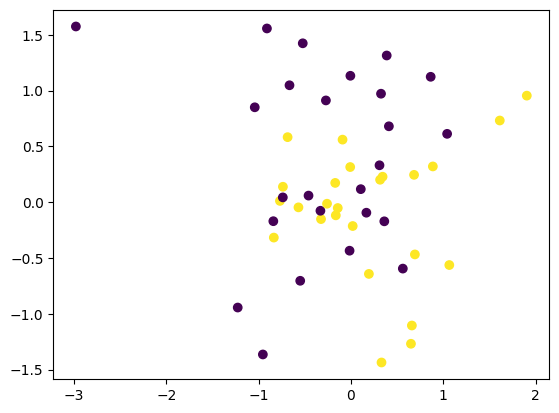

Базовый PNN accuracy:    0.6154
AdaptivePNN accuracy:    0.6923
Выученный bandwidth в AdaptivePNN: [17.7327  0.9115]
Сошёлся ли оптимизатор: False
Число итераций: 10000


In [10]:
# сложный синтетический датасет
X_ad, y_ad = make_classification(
    n_samples=50,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    class_sep=0.1,
    flip_y=0.01,
    random_state=42,
)
X_train_ad, X_test_ad, y_train_ad, y_test_ad = train_test_split(
    X_ad, y_ad, test_size=0.25, random_state=42, stratify=y_ad
)

plt.scatter(X_ad[:, 0], X_ad[:, 1], c=y_ad)
plt.show()

base_pnn = PNN(bandwidth=0.3, kernel="gaussian", losses="uniform")
base_pnn.fit(X_train_ad, y_train_ad)
base_pred = base_pnn.predict(X_test_ad)
base_acc = accuracy_score(y_test_ad, base_pred)

adaptive_pnn = AdaptivePNN(
    kernel="gaussian",
    losses="uniform",
    loss="log_likelihood_ratio",
    lr=0.01,
    eps=1e-6,
    max_iter=10000,
    tol=1e-6,
    verbose=False
)
adaptive_pnn.fit(X_train_ad, y_train_ad)
adaptive_pred = adaptive_pnn.predict(X_test_ad)
adaptive_acc = accuracy_score(y_test_ad, adaptive_pred)

print(f"Базовый PNN accuracy:    {base_acc:.4f}")
print(f"AdaptivePNN accuracy:    {adaptive_acc:.4f}")
print("Выученный bandwidth в AdaptivePNN:", np.round(adaptive_pnn.pattern_layer_.bandwidth_, 4))
print("Сошёлся ли оптимизатор:", adaptive_pnn.pattern_layer_.converged_)
print("Число итераций:", adaptive_pnn.pattern_layer_.n_iter_)